In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
weighted_returns_df = pd.read_csv("data/outputs/baseline_portfolio",
                                  index_col = 0, parse_dates = [1])
daily_df_annually = pd.read_csv("data/outputs/annually_reblanced_portfolio",
                                index_col = 0, parse_dates = [1])
daily_df_quarterly = pd.read_csv("data/outputs/quarterly_reblanced_portfolio",
                                 index_col = 0, parse_dates = [1])
daily_df_quarterly_band = pd.read_csv("data/outputs/quarterly_reblanced_byband_portfolio", 
                                      index_col = 0, parse_dates = [1])
annual_weights_frame = pd.read_csv("data/outputs/annually_rebalanced_weights",
                                index_col = 0, parse_dates=[1])
quarterly_weights_frame= pd.read_csv("data/outputs/quarterly_rebalanced_weights",
                                index_col = 0)
band_weights_frame = pd.read_csv("data/outputs/quarterly_rebalanced_byband_weights",
                                index_col = 0)

In [4]:
## Portfolio Drift ##

def drift_evaluation(df):
    starting_weights = df[df["weight_type"] == "starting"]
    ending_weights = df[df["weight_type"] == "ending"]

    difference = np.array(ending_weights.drop(columns=['Date','weight_type'])) - np.array(starting_weights.drop(columns=['Date','weight_type']))

    drift_list = []

    for period in range(len(difference)):
        start_date = starting_weights['Date'].iloc[period]
        end_date = ending_weights['Date'].iloc[period]

        drift = abs(difference[period]).sum()
        drift_list.append({
            "Start": start_date,
            "End" : end_date,
            "Drift": drift
            })

    return pd.DataFrame(drift_list)

In [5]:
## Trades ##
def calculate_trades(df):
    starting_weights = df[df["weight_type"] == "starting"]
    ending_weights = df[df["weight_type"] == "ending"]
    starting_weights_next = starting_weights.drop(starting_weights.index[0])
    ending_weights_current = ending_weights.drop(ending_weights.index[-1])
    start = starting_weights_next.drop(columns=['Date','weight_type'])
    end = ending_weights_current.drop(columns=['Date','weight_type'])
    trades = np.array(start) - np.array(end)
    trades_df = pd.DataFrame(trades, index = starting_weights_next['Date'], columns = start.columns)
    return trades_df


In [6]:

annual_trades_df = calculate_trades(annual_weights_frame)

,AGG,EEM,EFA,GLD,IWM,LQD,MTUM,QQQ,QUAL,SPY,TLT,USMV,VLUE,VNQ
Date,,,,,,,,,,,,,,
2023-01-03,-0.011494,0.000000e+00,-8.960803e-03,0.150000,1.500000e-01,0.150000,0.000000e+00,-0.041728,0.000000e+00,-0.101925,-1.276777e-01,-0.081914,0.060631,-1.369304e-01
2024-01-02,0.010076,2.884593e-17,-6.754119e-03,0.000757,-1.547203e-01,0.005111,2.259489e-17,0.150000,1.500000e-01,-0.005700,5.181237e-16,-0.034013,-0.114756,4.465968e-17
2025-01-02,0.016766,1.500000e-01,-1.360986e-01,-0.016569,-8.730215e-17,0.017359,1.500000e-01,-0.115151,-1.608208e-01,0.095253,-4.176816e-16,-0.000739,0.000000,-4.103932e-17
2026-01-02,0.020659,-1.166472e-02,5.308254e-16,-0.047497,1.242124e-16,0.019810,-1.473898e-01,0.001424,1.257812e-16,0.007956,4.662246e-16,0.006702,0.150000,0.000000e+00


In [100]:
## Turnover ## 
def calculate_turnover(df):
    turnover_list = []
    for row in range(len(df.index)):
        turnover = abs(df.iloc[row]).sum(axis = 0) * 0.5
        turnover_list.append({
            'Date':df.index[row],
            'turnover': turnover
            })
    return pd.DataFrame(turnover_list)


In [101]:
annual_portfolio_turnover = calculate_turnover(annual_trades_df)
annual_portfolio_turnover

,Date,turnover
0,2023-01-03,0.510631
1,2024-01-02,0.315944
2,2025-01-02,0.429378
3,2026-01-02,0.206552


In [134]:
def value_analysis(df, turnover_df, bp):

    tc = bp/10000

    df = df.copy()
    gross_value = df['portfolio_value']
    df2 = df.drop(columns = 'portfolio_value')

    turnover_series = turnover_df.set_index('Date').squeeze()

    df2['turnover'] = df2['Date'].map(turnover_series)

    previous_value = 1.0

    for index, row in df2.iterrows():

        past_value = previous_value
        growth = 1 + row["portfolio_return"]
        value = past_value * growth

        turnover = row["turnover"]

        if row["Rebalanced"] == 1 and pd.notna(turnover):
            cost = value * tc * turnover
        else:
            cost = 0

        portfolio_value = value - cost

        df2.loc[index, "past_value"] = past_value
        df2.loc[index, "growth"] = growth
        df2.loc[index, "value"] = value
        df2.loc[index, "cost"] = cost
        df2.loc[index, "portfolio_value"] = portfolio_value

        previous_value = portfolio_value

    df2['gross_value'] = gross_value
    return df2


In [ ]:
annual_value_adjusted = value_analysis(
    df = daily_df_annually,
    turnover_df=annual_portfolio_turnover,
    bp = 10
)

,Date,portfolio_return,rf_rate,running_peak,drawdown,Rebalanced,turnover,past_value,growth,value,cost,portfolio_value,gross_value
0,2022-01-03,-0.003996,0.000003,0.996004,0.0,1.0,NaN,1.000000,0.996004,0.996004,0.000000,0.996004,0.996004
251,2023-01-03,0.003561,0.000180,1.003561,0.0,1.0,0.510631,0.811157,1.003561,0.814046,0.000416,0.813630,0.814046
501,2024-01-02,-0.007469,0.000217,0.992531,0.0,1.0,0.315944,0.921705,0.992531,0.914821,0.000289,0.914532,0.915289
753,2025-01-02,0.002081,0.000173,1.002081,0.0,1.0,0.429378,1.049956,1.002081,1.052142,0.000452,1.051690,1.053012
1003,2026-01-02,0.007636,0.000145,1.007636,0.0,1.0,0.206552,1.301445,1.007636,1.311383,0.000271,1.311112,1.313031


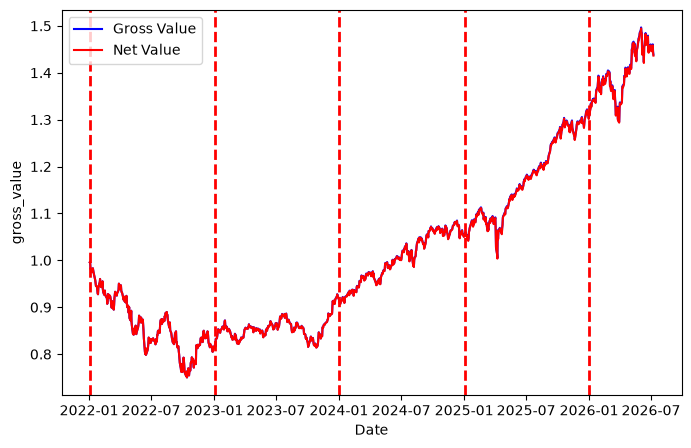

: 

In [ ]:
rebalance_days = annual_value_adjusted.loc[annual_value_adjusted['Rebalanced'] == 1, 'Date']
plt.figure(figsize= (8,5))

sns.lineplot(data = annual_value_adjusted, x = 'Date', y = 'gross_value', color='blue', label = "Gross Value")
sns.lineplot(data = annual_value_adjusted, x = 'Date', y = 'portfolio_value', color = 'red', label = "Net Value")

plt.legend()
for day in rebalance_days:
    plt.axvline(x=day, color="red", linestyle="--", linewidth=2)

## Weight Stability ## 
For each rebalance:

Compute turnover
T
Observe portfolio value before the rebalance
V
Assume transaction cost
c
Cost paid
Cost=V×T×c
New portfolio value
V
after
	​

=V−Cost

Holding Period Analysis

Questions

Average holding period

How often is each ETF traded?

Average position age

Number of consecutive quarters held